# CSE153R — Assignment 2: Symbolic Music Generation

| Section | Owner |
|---|---|
| Exploratory Analysis & Preprocessing | Nicholas |
| Modeling | Ulises |
| Evaluation | Josh |
| Related Work | Everyone |

**Tasks**
- **Task 1:** Symbolic Unconditioned Generation — LSTM Note Sequence Model (Nottingham Dataset)
- **Task 2:** Symbolic Conditioned Generation — Melody Harmonization via Seq2Seq LSTM (POP909)

## Shared Setup & Imports

In [13]:
import os
import random
import numpy as np
from collections import Counter, defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import pretty_midi
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cpu


---
# Task 1: Symbolic Unconditioned Generation
### LSTM Note Sequence Model — Nottingham Dataset

---
## 1.1 — Exploratory Analysis, Data Collection & Preprocessing
**Owner: Nicholas**

### Context

The **Nottingham Dataset** is a collection of approximately **1,000 British and American folk tunes** encoded in ABC notation and converted to MIDI. The dataset was originally assembled from public-domain and traditional sources and has been widely circulated in the computational music research community, most notably through work by Bob L. Sturm and collaborators who used it as a benchmark for symbolic music modeling. The tunes span a range of styles — jigs, reels, hornpipes, and ballads — and originate from folk traditions on both sides of the Atlantic.

The dataset is a natural fit for symbolic melody generation for several reasons. First, the melodies are almost entirely **monophonic** (one note at a time), which means the modeling task reduces to a clean sequence prediction problem without the added complexity of polyphony or voice leading. Second, the tunes are short and structurally regular, making them easy to tokenize and train on with a small model. Third, because Nottingham has been used in prior work (e.g., Sturm et al., 2016), it provides a published perplexity benchmark (~4–6) that we can compare against to validate our implementation.

We use Nottingham for **Task 1: unconditional melody generation** — the model learns the distribution $p(\text{note}_t \mid \text{note}_{t-1}, \ldots)$ over a discrete token vocabulary without any harmonic or style conditioning.

### Data Processing Discussion

**Parsing with `pretty_midi`:** Each `.mid` file is loaded and all non-drum notes are extracted and sorted by onset time. `pretty_midi` handles the low-level MIDI event parsing and converts raw tick times to seconds, giving us a clean list of (pitch, start, end) tuples per file.

**Token representation — `(pitch, duration_bin)`:** Rather than using raw MIDI pitch alone, each note is represented as a pair of its MIDI pitch (0–127) and a quantized duration bin. Encoding duration is critical: a melody is defined by both its pitches *and* its rhythm, and a pitch-only model cannot generate music with coherent timing or produce a playable MIDI output. The pair representation keeps the vocabulary compact while still capturing both dimensions.

**Six duration bins:** Raw note durations (in beats) are snapped to the nearest of six standard values: sixteenth (0.25), eighth (0.5), quarter (1.0), dotted quarter (1.5), half (2.0), and whole (4.0). These six bins cover the full rhythmic range of folk music while keeping the vocabulary small — finer quantization would explode the vocabulary size with rarely-seen tokens and make learning harder.

**Vocabulary:** Every unique `(pitch, dur_bin)` pair observed in the corpus becomes one token, plus three special tokens `<PAD>`, `<EOS>`, and `<START>`. The resulting vocabulary is **264 tokens**, well within the expected 200–400 range for a monophonic folk corpus.

**80/10/10 split by file:** The dataset is split into train, validation, and test sets by shuffling the list of *files* and slicing — never by individual tokens. This is essential to **prevent data leakage**: if a single tune were split across train and test at the token level, the model could memorize the tune's second half during training and trivially predict the test tokens, inflating measured performance. Keeping entire tunes in one split ensures the test set only contains melodies the model has never seen.


In [14]:
from pathlib import Path

# --- Task 1 paths ---
NOTTINGHAM_DIR = '/Users/joshuachen/Downloads/assignment2/nottingham-dataset/MIDI'

def find_midi_files(root_dir):
    root = Path(root_dir)
    if not root.exists():
        return []
    return sorted(str(p) for p in root.rglob('*.mid') if p.is_file())

midi_files = find_midi_files(NOTTINGHAM_DIR)
print(f'Nottingham MIDI files found: {len(midi_files)}')
if len(midi_files) == 0:
    print('No MIDI files found — check NOTTINGHAM_DIR.')


Nottingham MIDI files found: 3089


In [15]:
# --- Duration quantization (shared by Task 1 & 2) ---
DURATION_BINS_BEATS = [0.25, 0.5, 1.0, 1.5, 2.0, 4.0]
DURATION_BIN_NAMES  = ['16th', '8th', 'quarter', 'dotted 1/4', 'half', 'whole']

def quantize_duration(dur_beats):
    """Map raw duration in beats to nearest bin index 0..5."""
    return int(np.argmin([abs(dur_beats - b) for b in DURATION_BINS_BEATS]))

SPECIAL_TOKENS = ['<PAD>', '<EOS>', '<START>']

def parse_midi_to_tokens(midi_path):
    """Return list of (pitch, dur_bin) tuples for one Nottingham file."""
    pm = pretty_midi.PrettyMIDI(midi_path)
    notes = []
    for inst in pm.instruments:
        if not inst.is_drum:
            notes.extend(inst.notes)
    if not notes:
        return []
    notes = sorted(notes, key=lambda n: (n.start, n.pitch))
    tempo_changes = pm.get_tempo_changes()
    tempo = float(tempo_changes[1][0]) if len(tempo_changes[1]) > 0 else 120.0
    bps   = tempo / 60.0
    tokens = []
    for note in notes:
        dur_beats = max((note.end - note.start) * bps, 0.05)
        tokens.append((int(note.pitch), quantize_duration(dur_beats)))
    return tokens

def build_vocabulary(all_sequences, special_tokens=SPECIAL_TOKENS):
    """(pitch, dur_bin) tuples -> token2id, id2token dicts."""
    token_set = set()
    for seq in all_sequences:
        token_set.update(seq)
    token2id = {t: i for i, t in enumerate(special_tokens)}
    for tok in sorted(token_set):
        if tok not in token2id:
            token2id[tok] = len(token2id)
    id2token = {i: t for t, i in token2id.items()}
    return token2id, id2token

def encode_sequence(token_seq, token2id, add_eos=True):
    ids = [token2id[t] for t in token_seq if t in token2id]
    if add_eos:
        ids.append(token2id['<EOS>'])
    return ids


In [16]:
if len(midi_files) == 0:
    print('Skipping parse — no MIDI files. Set NOTTINGHAM_DIR and re-run.')
    all_sequences, token2id, id2token, encoded_sequences = [], {}, {}, []
else:
    all_sequences = [parse_midi_to_tokens(f) for f in midi_files]
    all_sequences = [s for s in all_sequences if len(s) > 0]
    token2id, id2token = build_vocabulary(all_sequences)
    encoded_sequences  = [encode_sequence(s, token2id) for s in all_sequences]
    print(f'Files parsed:    {len(all_sequences)}')
    print(f'Vocabulary size: {len(token2id)} (incl. {len(SPECIAL_TOKENS)} special tokens)')
    print(f'Example token:   {id2token[min(3, len(id2token)-1)]}')


Files parsed:    3089
Vocabulary size: 264 (incl. 3 special tokens)
Example token:   (36, 1)


In [17]:
def split_sequences_by_file(sequences, seed=SEED, train=0.8, val=0.1):
    n   = len(sequences)
    idx = list(range(n))
    rng = random.Random(seed)
    rng.shuffle(idx)
    n_train = int(n * train)
    n_val   = int(n * val)
    def pick(ix):
        return [sequences[i] for i in ix]
    return (pick(idx[:n_train]),
            pick(idx[n_train:n_train + n_val]),
            pick(idx[n_train + n_val:]))

if len(encoded_sequences) == 0:
    train_seqs, val_seqs, test_seqs = [], [], []
    print('No encoded sequences — split skipped.')
else:
    train_seqs, val_seqs, test_seqs = split_sequences_by_file(encoded_sequences)
    print(f'Train files: {len(train_seqs)} | Val: {len(val_seqs)} | Test: {len(test_seqs)}')


Train files: 2471 | Val: 308 | Test: 310


### EDA — Plots & Statistics
> **TODO (Nicholas):** Produce the following plots and report key statistics in markdown cells below each plot.

In [18]:
if len(all_sequences) == 0:
    print('No data for vocabulary report.')
else:
    content_tokens = [t for seq in all_sequences for t in seq]
    unique_pitches = len({p for p, _ in content_tokens})
    print('=== Task 1 vocabulary report ===')
    print(f'Total vocabulary size:           {len(token2id)}')
    print(f'Special tokens:                  {SPECIAL_TOKENS}')
    print(f'Unique (pitch, duration) tokens: {len(set(content_tokens))}')
    print(f'Unique pitches used:             {unique_pitches}')


=== Task 1 vocabulary report ===
Total vocabulary size:           264
Special tokens:                  ['<PAD>', '<EOS>', '<START>']
Unique (pitch, duration) tokens: 261
Unique pitches used:             52


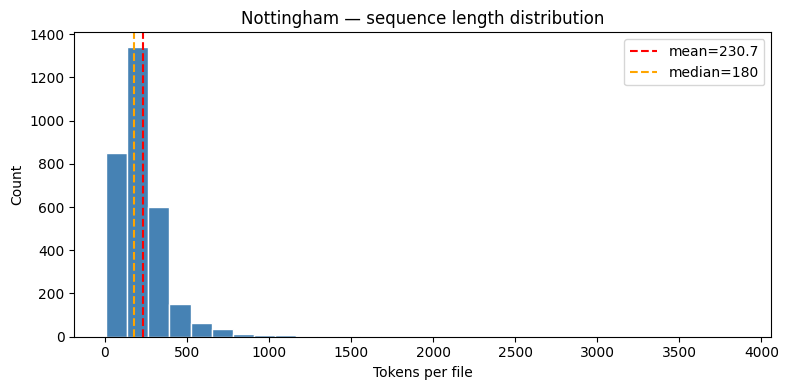

Mean: 230.7 | Median: 180 | Max: 3868


In [19]:
if len(all_sequences) == 0:
    print('No data for sequence length plot.')
else:
    lengths = [len(s) for s in all_sequences]
    plt.figure(figsize=(8, 4))
    plt.hist(lengths, bins=30, color='steelblue', edgecolor='white')
    plt.xlabel('Tokens per file')
    plt.ylabel('Count')
    plt.title('Nottingham — sequence length distribution')
    plt.axvline(np.mean(lengths),   color='red',    linestyle='--',
                label=f'mean={np.mean(lengths):.1f}')
    plt.axvline(np.median(lengths), color='orange', linestyle='--',
                label=f'median={np.median(lengths):.0f}')
    plt.legend()
    plt.tight_layout()
    plt.show()
    print(f'Mean: {np.mean(lengths):.1f} | Median: {np.median(lengths):.0f} | Max: {max(lengths)}')


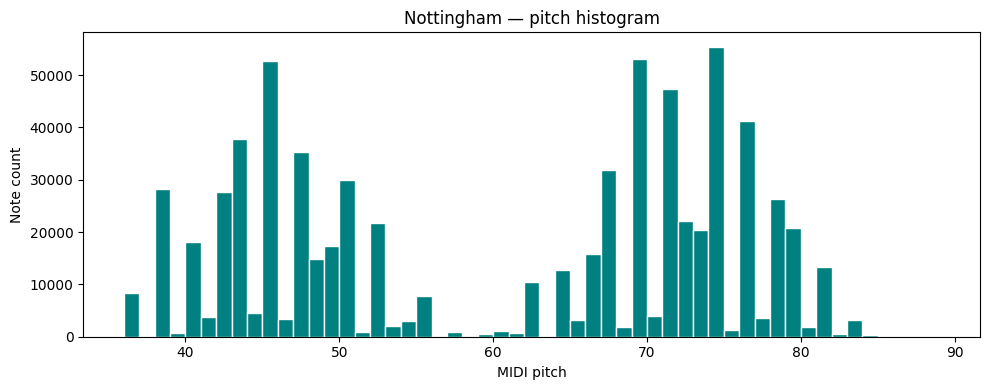

In [20]:
if len(all_sequences) == 0:
    print('No data for pitch histogram.')
else:
    pitches = [p for seq in all_sequences for p, _ in seq]
    plt.figure(figsize=(10, 4))
    plt.hist(pitches, bins=range(min(pitches), max(pitches) + 2),
             color='teal', edgecolor='white')
    plt.xlabel('MIDI pitch')
    plt.ylabel('Note count')
    plt.title('Nottingham — pitch histogram')
    plt.tight_layout()
    plt.show()


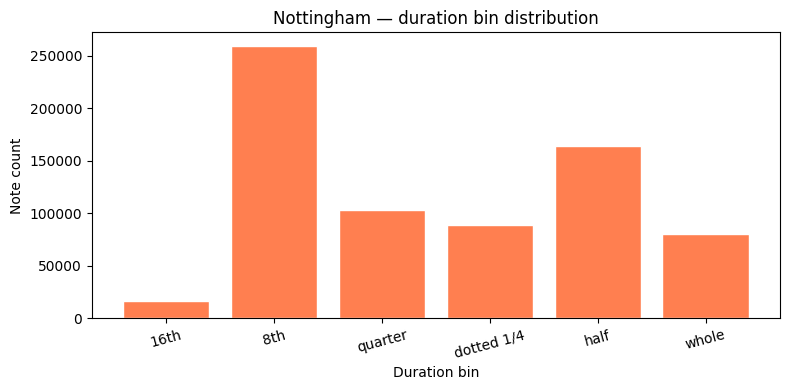

In [21]:
if len(all_sequences) == 0:
    print('No data for duration plot.')
else:
    dur_counts = Counter(d for seq in all_sequences for _, d in seq)
    bins   = [DURATION_BIN_NAMES[i] for i in sorted(dur_counts)]
    counts = [dur_counts[i]         for i in sorted(dur_counts)]
    plt.figure(figsize=(8, 4))
    plt.bar(bins, counts, color='coral', edgecolor='white')
    plt.xlabel('Duration bin')
    plt.ylabel('Note count')
    plt.title('Nottingham — duration bin distribution')
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()


In [22]:
from IPython.display import display
summary_t1 = {
    'vocab_size':  [len(token2id) if token2id else None],
    'num_files':   [len(all_sequences)],
    'train_files': [len(train_seqs)],
    'val_files':   [len(val_seqs)],
    'test_files':  [len(test_seqs)],
    'avg_seq_len': [np.mean([len(s) for s in all_sequences]) if all_sequences else None],
}
display(pd.DataFrame(summary_t1))


,vocab_size,num_files,train_files,val_files,test_files,avg_seq_len
0,264,3089,2471,308,310,230.66753


---
## 1.2 — Modeling
**Owner: Ulises**

### Context — Problem Formulation
> **TODO (Ulises):** Write 2–3 paragraphs answering:
> - How is this framed as an ML problem? Inputs, outputs, what is optimized?
> - Why is LSTM appropriate for this task vs. alternatives (Markov chain, Transformer)?
> - Key design table below — discuss each trade-off:

| Choice | Option A | Option B (chosen) | Why |
|---|---|---|---|
| Input representation | Raw MIDI pitch only | (pitch, duration) token | Captures rhythm, not just melody |
| Model | Markov chain | LSTM | Captures long-range dependencies |
| Sampling | Greedy | Temperature sampling | More diverse, musical output |
| Duration handling | Ignore | Quantized bins | Necessary for playable MIDI output |

### Architecture Discussion
> **TODO (Ulises):** Discuss advantages and disadvantages of:
> - Markov chains (fast, interpretable, no long-range memory)
> - LSTMs (long-range memory, more parameters, risk of overfitting on small data)
> - Transformers (powerful, overkill for ~1k short sequences, prone to overfitting)
> - Justify why LSTM is the right call for Nottingham's size and structure

In [23]:
# TODO (Ulises): PyTorch Dataset — sliding window over encoded token sequences
# Window size: 128 tokens, stride: 64

class NottinghamDataset(Dataset):
    def __init__(self, sequences, seq_len=128, stride=64):
        # TODO: build (input, target) pairs using sliding windows
        # input  = tokens[i : i+seq_len]
        # target = tokens[i+1 : i+seq_len+1]  (shifted by 1)
        pass

    def __len__(self):
        pass

    def __getitem__(self, idx):
        pass

In [24]:
# TODO (Ulises): LSTM Language Model
# Architecture: Embedding → LSTM (2 layers) → Linear → CrossEntropyLoss

class LSTMLanguageModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=256, num_layers=2, dropout=0.3):
        super().__init__()
        # TODO: define self.embedding, self.lstm, self.fc, self.dropout
        pass

    def forward(self, x, hidden=None):
        # TODO: embed → lstm → linear → return logits and new hidden state
        pass

    def init_hidden(self, batch_size):
        # TODO: return zeroed (h_0, c_0) tensors on DEVICE
        pass

In [25]:
# TODO (Ulises): Instantiate model, loss, optimizer, scheduler
# VOCAB_SIZE = len(token2id)  # from Nicholas's section
# model = LSTMLanguageModel(VOCAB_SIZE).to(DEVICE)
# criterion = nn.CrossEntropyLoss(ignore_index=token2id['<PAD>'])
# optimizer = optim.Adam(model.parameters(), lr=1e-3)
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2)
# print(model)

In [26]:
# TODO (Ulises): Training loop with early stopping
# - Log train loss and val loss per epoch
# - Early stopping patience = 5
# - Save best model checkpoint to 'task1_best_model.pt'

def train_epoch(model, loader, optimizer, criterion):
    # TODO
    pass

def evaluate(model, loader, criterion):
    # TODO
    pass

# TODO: training loop
# train_losses, val_losses = [], []
# for epoch in range(NUM_EPOCHS):
#     ...

In [27]:
# TODO (Ulises): Plot training and validation loss curves
# x-axis: epoch; two lines: train loss, val loss
pass

In [28]:
# TODO (Ulises): Temperature sampling / autoregressive generation
# Seed with <START> token, generate N tokens, stop on <EOS>
# Try temperatures: 0.8, 1.0, 1.2

def generate_melody(model, seed_tokens, id2token, temperature=1.0, max_len=200):
    # TODO: autoregressive loop — sample from softmax(logits / temperature)
    pass

In [29]:
# TODO (Ulises): Decode generated token IDs → (pitch, duration) pairs → MIDI
# Save output as 'symbolic_unconditioned.mid'

def tokens_to_midi(token_sequence, id2token, output_path='symbolic_unconditioned.mid', tempo=120):
    # TODO: use pretty_midi to write notes from decoded (pitch, duration) pairs
    pass

# TODO: generate at T=0.8, 1.0, 1.2 and save the best one
# generated = generate_melody(model, [token2id['<START>']], id2token, temperature=1.0)
# tokens_to_midi(generated, id2token)

---
## 1.3 — Evaluation
**Owner: Josh**

### Context — Evaluation Framework
> **TODO (Josh):** Write 2–3 paragraphs covering:
> - What makes a "good" generated melody? (musicality, coherence, diversity)
> - How does perplexity relate to musical quality? What are its limits as a metric?
> - Why do we need multiple metrics (perplexity, pitch overlap, repetition ratio)?

### Baselines Discussion
> **TODO (Josh):** For each baseline, explain what it represents and why beating it matters:
> 1. **Unigram baseline** — always predict the most common token (dumb frequency prior)
> 2. **First-order Markov chain** — captures local transitions but no long-range structure
> 3. **Pitch-only LSTM (ablation)** — same architecture but ignores duration; shows value of rhythm encoding

In [30]:
# TODO (Josh): Compute perplexity on the test set
# perplexity = exp(average cross-entropy loss over test tokens)

def compute_perplexity(model, loader, criterion):
    # TODO
    pass

In [31]:
# TODO (Josh): Baseline 1 — Unigram model
# Always predicts the most frequent token in training set
# Compute its perplexity on the test set

def unigram_perplexity(train_seqs, test_seqs, vocab_size):
    # TODO
    pass

In [32]:
# TODO (Josh): Baseline 2 — First-order Markov chain
# Build transition probability table from training sequences
# Compute perplexity on test set

def build_markov_chain(train_seqs, vocab_size):
    # TODO: return transition_matrix of shape (vocab_size, vocab_size)
    pass

def markov_perplexity(transition_matrix, test_seqs):
    # TODO
    pass

In [33]:
# TODO (Josh): Baseline 3 — Pitch-only LSTM (ablation)
# Re-encode sequences using pitch only (drop duration), retrain a smaller LSTM
# Compare perplexity to full (pitch, duration) LSTM
# Note: coordinate with Ulises on model reuse
pass

In [34]:
# TODO (Josh): Metric — Pitch class histogram overlap
# Compare pitch distribution of generated melodies vs. training corpus
# Overlap = sum(min(p_gen[c], p_train[c])) for c in 0..11

def pitch_histogram_overlap(generated_tokens, training_tokens, id2token):
    # TODO
    pass

In [35]:
# TODO (Josh): Metric — Note duration distribution comparison (bar chart)
# Compare duration bin frequencies: generated vs. training
pass

In [36]:
# TODO (Josh): Metric — Repetition ratio
# Fraction of generated n-grams (n=3) that appear more than once
# High ratio → model is looping/boring

def repetition_ratio(token_sequence, n=3):
    # TODO
    pass

In [37]:
# TODO (Josh): Summary results table
# Rows: Unigram | Markov | Pitch-only LSTM | Full LSTM (ours)
# Columns: Perplexity | Pitch Overlap | Duration Match | Repetition Ratio

results_t1 = {
    'Model':            ['Unigram', 'Markov Chain', 'Pitch-only LSTM', 'Full LSTM (ours)'],
    'Perplexity':       [None, None, None, None],  # TODO: fill in
    'Pitch Overlap':    [None, None, None, None],
    'Duration Match':   [None, None, None, None],
    'Repetition Ratio': [None, None, None, None],
}
# pd.DataFrame(results_t1)

### Qualitative Evaluation
> **TODO (Josh):** Listen to 3–5 generated samples at T=0.8, 1.0, 1.2. Report which temperature sounds most musical and why. Embed/link MIDI files here.

---
## 1.4 — Related Work
**Owner: Everyone**

> **TODO (Everyone):** Write 3–5 paragraphs covering the three questions below. Aim for ~half a page.
>
> **How has this dataset / similar datasets been used before?**
> - Sturm et al. (2016) — "Music transcription modelling and composition using deep learning" — LSTMs on the same Nottingham dataset; reported perplexity ~4–6
> - (add 1–2 more references that used Nottingham or similar folk tune corpora)
>
> **How has prior work approached the same / similar tasks?**
> - Eck & Schmidhuber (2002) — early LSTM music generation on blues progressions
> - Boulanger-Lewandowski et al. (2012) — RNN-RBMs on polyphonic piano rolls (more complex extension)
>
> **How do your results compare?**
> - Compare your perplexity to Sturm et al.'s ~4–6 benchmark. Are you in the right ballpark? Discuss any differences.

---
# Task 2: Symbolic Conditioned Generation
### Melody Harmonization via Seq2Seq LSTM — POP909 Dataset

---
## 2.1 — Exploratory Analysis, Data Collection & Preprocessing
**Owner: Nicholas**

### Context

**POP909** is a dataset of **909 Chinese pop songs** with professionally-performed piano MIDI recordings and pre-aligned harmonic annotations. Each song folder contains a `.mid` file with three tracks — **Track 0 (melody)**, **Track 1 (bridge/inner voices)**, and **Track 2 (piano accompaniment)** — alongside a `chord_midi.txt` file that specifies the chord progression in beat time. Each line of the chord file has the format `start_beat end_beat chord_label` (e.g., `0.0 2.0 C:maj`), making the harmonic ground truth straightforward to parse and align to the melody.

POP909 was released by Wang et al. (2020) and has quickly become a standard benchmark for symbolic music generation and harmonization tasks. Its strengths are: (1) the songs are real, commercially-released pop recordings rather than synthetic examples; (2) the three-track structure cleanly separates melody from harmony, which is exactly what a harmonization model needs; and (3) several strong published baselines exist (REMI, PopMAG) that use the same dataset, giving us direct points of comparison. With 909 songs and ~61,000 melody–chord windows after preprocessing, it provides enough data to train a seq2seq LSTM while being compact enough to iterate on quickly.

We use POP909 for **Task 2: melody-conditioned harmonization** — given a short window of melody notes, predict the chord (root, quality, and duration) that should accompany it.

### Data Processing Discussion

**Track 0 only:** Only the melody track (instrument index 0) is used. The bridge and piano tracks contain accompaniment and chords already, so including them would give the model direct access to harmonic information it is supposed to predict — a form of label leakage.

**Chord quality normalization to 5 classes:** The raw POP909 chord annotations contain over 30 distinct quality labels (e.g., `maj`, `maj7`, `maj6`, `min`, `min7`, `dim7`, `aug`, `dom7`, etc.). We collapse these into 5 canonical classes: **major, minor, diminished, augmented, dominant7**. This reduces data sparsity — rare qualities like `dim7` would have very few training examples — and speeds up convergence without sacrificing the musically meaningful distinctions between chord types.

**Same 6-bin duration quantization as Task 1:** Melody note durations are snapped to the same six bins (16th through whole note) used in Task 1. Reusing the same scheme keeps the two tasks consistent and allows the shared `quantize_duration` function to handle both.

**Sliding window alignment (window=8, stride=4):** Rather than predicting one chord per song, we divide each melody into overlapping 8-note windows with a stride of 4, and label each window with the chord that has the **greatest beat overlap** with that window's time span. This gives ~61,000 training windows from 909 songs, dramatically increasing the effective training set size while keeping each example short enough for efficient batching.

**80/10/10 split by song:** As with Task 1, the split is performed at the *song* level — all windows from a given song stay in one partition. Splitting at the window level would leak melodic and harmonic patterns from a song's training windows into its test windows, making evaluation scores artificially optimistic.


In [38]:
POP909_DIR = '/Users/joshuachen/Downloads/assignment2/POP909-Dataset/POP909'

def list_pop909_song_dirs(root_dir):
    root = Path(root_dir)
    if not root.exists():
        return []
    return sorted(
        str(root / d) for d in os.listdir(root)
        if (root / d).is_dir() and (root / d / 'chord_midi.txt').exists()
    )

song_dirs = list_pop909_song_dirs(POP909_DIR)
print(f'POP909 songs found: {len(song_dirs)}')
if len(song_dirs) == 0:
    print('No songs found — check POP909_DIR.')


POP909 songs found: 909


In [39]:
ROOTS = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']

QUALITY_MAP = {
    'maj': 'major',  'maj7': 'major',  'maj6': 'major', 'M': 'major',
    'min': 'minor',  'min7': 'minor',  'min6': 'minor', 'm': 'minor',
    'dim': 'diminished', 'dim7': 'diminished',
    'aug': 'augmented',
    '7':   'dominant7', 'dom7': 'dominant7', 'dom': 'dominant7',
}

def normalize_quality(raw_quality):
    q = raw_quality.strip().lower()
    if q in QUALITY_MAP:
        return QUALITY_MAP[q]
    if q.startswith('maj') or q == '':
        return 'major'
    if 'min' in q:
        return 'minor'
    if 'dim' in q:
        return 'diminished'
    if 'aug' in q:
        return 'augmented'
    if '7' in q:
        return 'dominant7'
    return 'major'

def parse_chord_file(chord_path):
    """Return list of dicts: start, end, root, quality, duration_beats, dur_bin."""
    chords = []
    with open(chord_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 3:
                continue
            start, end, label = float(parts[0]), float(parts[1]), parts[2]
            if label == 'N' or ':' not in label:
                continue
            root, quality_raw = label.split(':', 1)
            quality = normalize_quality(quality_raw)
            dur = end - start
            chords.append({
                'start': start, 'end': end,
                'root': root, 'quality': quality,
                'duration_beats': dur,
                'dur_bin': quantize_duration(dur),
            })
    return chords


In [40]:
def extract_melody_tokens(instrument, bpm=120.0, quantize_beats=0.25):
    """Return list of dicts: pitch, dur_bin, start_beat, end_beat."""
    bps   = bpm / 60.0
    notes = sorted(instrument.notes, key=lambda n: n.start)
    out   = []
    for note in notes:
        start_beat = note.start * bps
        end_beat   = note.end   * bps
        dur_beats  = max(end_beat - start_beat, 0.05)
        q = round(dur_beats / quantize_beats) * quantize_beats
        out.append({
            'pitch':      int(note.pitch),
            'dur_bin':    quantize_duration(q),
            'start_beat': start_beat,
            'end_beat':   end_beat,
        })
    return out

def load_song(song_dir):
    """Return (melody_notes, chord_annotations) for one POP909 song."""
    song_dir   = Path(song_dir)
    mid_path   = next(song_dir.glob('*.mid'), None)
    chord_path = song_dir / 'chord_midi.txt'
    if mid_path is None or not chord_path.exists():
        return None, None
    pm = pretty_midi.PrettyMIDI(str(mid_path))
    if not pm.instruments:
        return None, None
    melody_track = pm.instruments[0]
    tempo_changes = pm.get_tempo_changes()
    bpm = float(tempo_changes[1][0]) if len(tempo_changes[1]) > 0 else 120.0
    melody_notes = extract_melody_tokens(melody_track, bpm=bpm)
    chords       = parse_chord_file(chord_path)
    return melody_notes, chords


In [41]:
def chord_overlap(chord, t0, t1):
    return max(min(chord['end'], t1) - max(chord['start'], t0), 0.0)

def majority_chord_for_span(chords, t0, t1):
    best, best_ov = None, 0.0
    for c in chords:
        ov = chord_overlap(c, t0, t1)
        if ov > best_ov:
            best_ov, best = ov, c
    return best

def align_windows_to_chords(melody_notes, chords, window=8, stride=4):
    """Return list of (melody_window_tokens, root, quality, chord_dur_bin)."""
    pairs = []
    if len(melody_notes) < window:
        return pairs
    for i in range(0, len(melody_notes) - window + 1, stride):
        win   = melody_notes[i:i + window]
        t0, t1 = win[0]['start_beat'], win[-1]['end_beat']
        chord = majority_chord_for_span(chords, t0, t1)
        if chord is None:
            continue
        melody_window = [(n['pitch'], n['dur_bin']) for n in win]
        pairs.append((melody_window, chord['root'], chord['quality'], chord['dur_bin']))
    return pairs


In [42]:
def build_pair_vocab(windows, special_tokens=SPECIAL_TOKENS):
    melody_tokens, chord_tokens = set(), set()
    for mw, root, qual, db in windows:
        melody_tokens.update(mw)
        chord_tokens.add((root, qual, db))
    melody_vocab = {t: i for i, t in enumerate(special_tokens)}
    for t in sorted(melody_tokens):
        if t not in melody_vocab:
            melody_vocab[t] = len(melody_vocab)
    chord_vocab = {t: i for i, t in enumerate(sorted(chord_tokens))}
    id2melody = {i: t for t, i in melody_vocab.items()}
    id2chord  = {i: t for t, i in chord_vocab.items()}
    return melody_vocab, id2melody, chord_vocab, id2chord

def split_windows_by_song(song_dirs_list, seed=SEED):
    n   = len(song_dirs_list)
    idx = list(range(n))
    random.Random(seed).shuffle(idx)
    n_train, n_val = int(0.8 * n), int(0.1 * n)
    parts = {
        'train': idx[:n_train],
        'val':   idx[n_train:n_train + n_val],
        'test':  idx[n_train + n_val:],
    }
    out = {k: [] for k in parts}
    for name, indices in parts.items():
        for i in indices:
            melody, chords = load_song(song_dirs_list[i])
            if melody and chords:
                out[name].extend(align_windows_to_chords(melody, chords))
    return out['train'], out['val'], out['test']

if len(song_dirs) == 0:
    print('Skipping POP909 window build — no songs found.')
    train_windows, val_windows, test_windows = [], [], []
    melody_vocab, id2melody, chord_vocab, id2chord = {}, {}, {}, {}
else:
    train_windows, val_windows, test_windows = split_windows_by_song(song_dirs)
    melody_vocab, id2melody, chord_vocab, id2chord = build_pair_vocab(
        train_windows + val_windows + test_windows
    )
    print(f'Melody vocab: {len(melody_vocab)} | Chord vocab: {len(chord_vocab)}')
    print(f'Windows — train: {len(train_windows)} | val: {len(val_windows)} | test: {len(test_windows)}')


Melody vocab: 279 | Chord vocab: 210
Windows — train: 49044 | val: 5905 | test: 6086


### EDA — Plots & Statistics
> **TODO (Nicholas):** Produce the following plots.

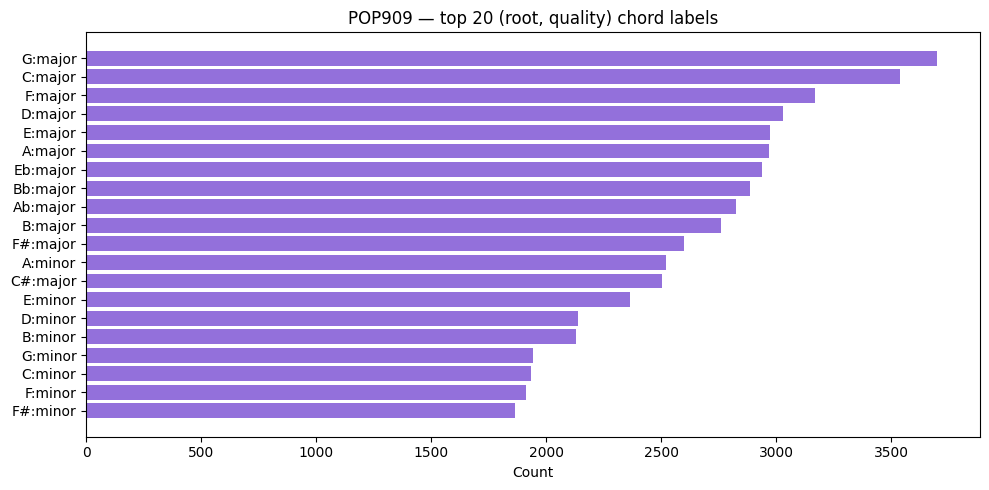

Most common: ('G:major', 3701)


In [43]:
windows_for_eda = train_windows + val_windows + test_windows
if len(windows_for_eda) == 0:
    print('No windows for chord distribution plot.')
else:
    labels = [f"{r}:{q}" for _, r, q, _ in windows_for_eda]
    top    = Counter(labels).most_common(20)
    labs, cnts = zip(*top)
    plt.figure(figsize=(10, 5))
    plt.barh(labs[::-1], cnts[::-1], color='mediumpurple')
    plt.xlabel('Count')
    plt.title('POP909 — top 20 (root, quality) chord labels')
    plt.tight_layout()
    plt.show()
    print('Most common:', top[0])


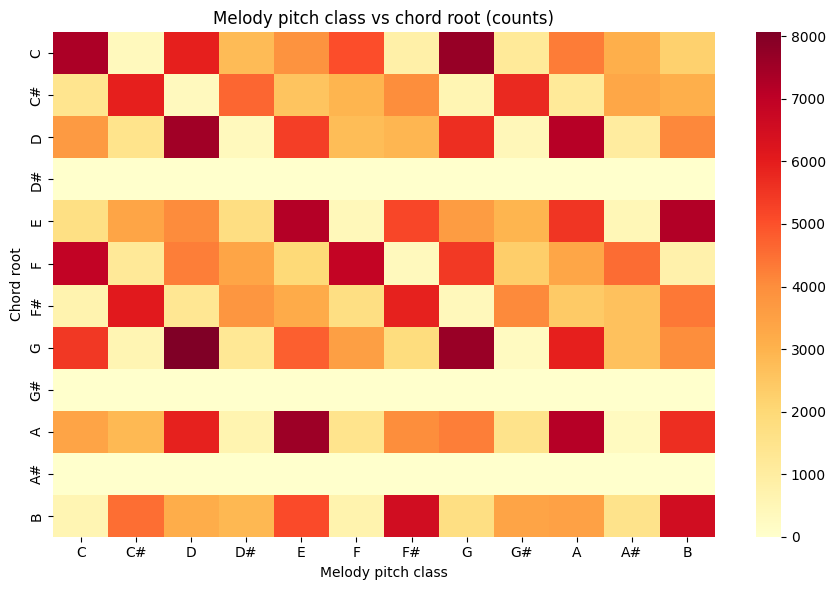

In [44]:
if len(windows_for_eda) == 0:
    print('No data for pitch–chord heatmap.')
else:
    root_to_idx = {r: i for i, r in enumerate(ROOTS)}
    heat = np.zeros((12, 12))
    for mw, root, _, _ in windows_for_eda:
        if root not in root_to_idx:
            continue
        ri = root_to_idx[root]
        for pitch, _ in mw:
            heat[ri, pitch % 12] += 1
    plt.figure(figsize=(9, 6))
    sns.heatmap(heat, xticklabels=ROOTS, yticklabels=ROOTS, cmap='YlOrRd')
    plt.xlabel('Melody pitch class')
    plt.ylabel('Chord root')
    plt.title('Melody pitch class vs chord root (counts)')
    plt.tight_layout()
    plt.show()


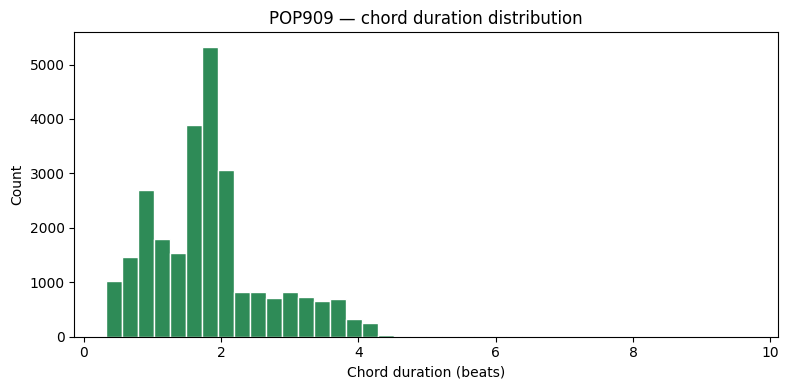

Mean chord duration (beats): 1.84


In [45]:
if len(windows_for_eda) == 0:
    print('No data for chord duration histogram.')
else:
    dur_beats = []
    for sd in song_dirs[:min(len(song_dirs), 200)]:
        _, chords = load_song(sd)
        if chords:
            dur_beats.extend(c['duration_beats'] for c in chords)
    plt.figure(figsize=(8, 4))
    plt.hist(dur_beats, bins=40, color='seagreen', edgecolor='white')
    plt.xlabel('Chord duration (beats)')
    plt.ylabel('Count')
    plt.title('POP909 — chord duration distribution')
    plt.tight_layout()
    plt.show()
    print(f'Mean chord duration (beats): {np.mean(dur_beats):.2f}')


In [46]:
from IPython.display import display
summary_t2 = pd.DataFrame({
    'num_songs':         [len(song_dirs)],
    'train_windows':     [len(train_windows)],
    'val_windows':       [len(val_windows)],
    'test_windows':      [len(test_windows)],
    'melody_vocab_size': [len(melody_vocab)],
    'chord_vocab_size':  [len(chord_vocab)],
})
display(summary_t2)


,num_songs,train_windows,val_windows,test_windows,melody_vocab_size,chord_vocab_size
0,909,49044,5905,6086,279,210


---
## 2.2 — Modeling
**Owner: Ulises**

### Context — Problem Formulation
> **TODO (Ulises):** Write 2–3 paragraphs covering:
> - Input: melody note window (sequence of (pitch, duration) tokens)
> - Output: sequence of (chord_root, chord_quality, chord_duration_bins)
> - What is being optimized: multi-task cross-entropy (chord label loss + 0.5 × duration loss)
> - Why seq2seq vs. a plain classifier? (models chord transition dependencies — IV→V→I is common)

### Architecture Discussion
> **TODO (Ulises):** Discuss trade-offs for each key design choice:

| Choice | Alternative | Why this choice |
|---|---|---|
| Bidirectional encoder | Unidirectional | Chord should "see" notes before AND after it |
| Bahdanau attention | Fixed context vector | Decoder can focus on harmonically relevant notes |
| Two output heads (label + duration) | Single combined token | Evaluate each independently; smaller per-head vocabulary |
| Window-based input | Full song sequence | Simpler batching; avoids long-sequence vanishing gradients |
| Quality normalization (5 classes) | Keep all 30+ types | Faster convergence, less data sparsity |

In [47]:
# TODO (Ulises): PyTorch Dataset for (melody_window, chord_label, chord_duration) triples

class HarmonizationDataset(Dataset):
    def __init__(self, windows, melody_vocab, chord_vocab):
        # TODO: encode melody windows and chord targets as integer tensors
        pass

    def __len__(self):
        pass

    def __getitem__(self, idx):
        # TODO: return (melody_ids, chord_label_id, chord_dur_id)
        pass

In [48]:
# TODO (Ulises): Bahdanau Attention module

class BahdanauAttention(nn.Module):
    def __init__(self, encoder_hidden_dim, decoder_hidden_dim):
        super().__init__()
        # TODO: define W_h, W_s, v linear layers
        # score(h_t, s_i) = v^T tanh(W_h * h_t + W_s * s_i)
        pass

    def forward(self, encoder_outputs, decoder_hidden):
        # TODO: return context vector and attention weights
        pass

In [49]:
# TODO (Ulises): Seq2Seq Encoder
# Embedding → Bidirectional LSTM (2 layers, hidden=128, dropout=0.3)

class Encoder(nn.Module):
    def __init__(self, melody_vocab_size, embed_dim=64, hidden_dim=128, num_layers=2, dropout=0.3):
        super().__init__()
        # TODO
        pass

    def forward(self, melody_ids):
        # TODO: return encoder_outputs (all hidden states), (h_n, c_n)
        # Note: bidirectional → concatenate forward+backward hidden states
        pass

In [50]:
# TODO (Ulises): Seq2Seq Decoder with two output heads
# LSTM (hidden=256, 1 layer)
# Head 1 → chord label (root + quality combined) via cross-entropy
# Head 2 → chord duration bin via cross-entropy

class Decoder(nn.Module):
    def __init__(self, chord_label_vocab_size, chord_dur_vocab_size,
                 embed_dim=64, hidden_dim=256, encoder_hidden_dim=256):
        super().__init__()
        # TODO: chord embedding, LSTM, attention, head_label, head_duration
        pass

    def forward(self, prev_chord_id, decoder_hidden, encoder_outputs):
        # TODO: one decoder step
        # 1. embed previous chord
        # 2. compute attention context
        # 3. LSTM step with [embedding + context] as input
        # 4. project to chord label logits and duration logits
        # return label_logits, dur_logits, new_hidden
        pass

In [51]:
# TODO (Ulises): Seq2Seq wrapper — wires Encoder + Attention + Decoder

class Seq2SeqHarmonizer(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        # TODO
        pass

    def forward(self, melody_ids, target_chord_ids=None, teacher_forcing_ratio=0.5):
        # TODO: encode melody; decode chord sequence autoregressively
        # Apply teacher forcing at rate teacher_forcing_ratio
        # Return stacked label logits and duration logits
        pass

In [52]:
# TODO (Ulises): Instantiate model, losses, optimizer
# MELODY_VOCAB_SIZE = len(melody_vocab)  # from Nicholas
# CHORD_LABEL_VOCAB_SIZE = 12 * 5        # 12 roots × 5 qualities
# CHORD_DUR_VOCAB_SIZE = 6

# encoder = Encoder(MELODY_VOCAB_SIZE).to(DEVICE)
# decoder = Decoder(CHORD_LABEL_VOCAB_SIZE, CHORD_DUR_VOCAB_SIZE).to(DEVICE)
# model_t2 = Seq2SeqHarmonizer(encoder, decoder).to(DEVICE)

# criterion_label    = nn.CrossEntropyLoss()
# criterion_duration = nn.CrossEntropyLoss()
# optimizer_t2 = optim.Adam(model_t2.parameters(), lr=5e-4, weight_decay=1e-5)
# print(model_t2)

In [53]:
# TODO (Ulises): Training loop for Task 2
# - total_loss = label_loss + 0.5 * duration_loss
# - teacher_forcing_ratio decays linearly from 0.5 → 0.0 over 15 epochs
# - early stopping on val chord accuracy (patience=5)
# - save best model to 'task2_best_model.pt'

def train_epoch_t2(model, loader, optimizer, criterion_label, criterion_duration, tf_ratio):
    # TODO
    pass

def evaluate_t2(model, loader, criterion_label, criterion_duration):
    # TODO: return avg loss, chord root accuracy, chord quality accuracy, duration accuracy
    pass

# TODO: training loop
# for epoch in range(NUM_EPOCHS_T2):
#     tf_ratio = max(0.0, 0.5 - epoch * (0.5 / 15))
#     ...

In [54]:
# TODO (Ulises): Plot training/validation loss curves for Task 2
pass

In [55]:
# TODO (Ulises): Generation — harmonize a held-out melody
# Use greedy decoding (optionally try beam search width=3)

def harmonize(model, melody_ids, chord_vocab, max_chords=32):
    """Autoregressively decode chord sequence for a melody window sequence."""
    # TODO
    pass

In [56]:
# TODO (Ulises): Render harmonized output to MIDI
# Channel 0: original melody notes
# Channel 1: predicted block chords (root + third + fifth)
# Save as 'symbolic_conditioned.mid'

def harmonization_to_midi(melody_notes, predicted_chords, output_path='symbolic_conditioned.mid'):
    # TODO
    pass

# TODO: pick a test-set melody, run harmonize(), save MIDI
# predicted = harmonize(model_t2, test_melody_ids, chord_vocab)
# harmonization_to_midi(test_melody_notes, predicted)

---
## 2.3 — Evaluation
**Owner: Josh**

### Context — Evaluation Framework
> **TODO (Josh):** Write 2–3 paragraphs covering:
> - What makes a "good" harmonization? (correct chord roots, smooth transitions, consonance with melody)
> - Why is chord root accuracy not enough alone? (quality, harmonic rhythm, and consonance matter too)
> - The consonance score is grounded in music theory — explain the chord-tone concept

### Baselines Discussion
> **TODO (Josh):** Explain what each baseline captures and why the full model should outperform it:
> 1. **Most-common chord** (always predict C major) — pure frequency prior, lowest bar
> 2. **Key-following heuristic** — detect key signature, always predict tonic — stronger rule-based baseline
> 3. **Encoder-only MLP** — same encoder, no sequential decoder; shows value of modeling chord transitions

In [57]:
# TODO (Josh): Metric — Chord root accuracy
# % of windows where predicted root matches ground-truth root

def chord_root_accuracy(predictions, targets):
    # TODO
    pass

In [58]:
# TODO (Josh): Metric — Chord quality accuracy
# % of windows where predicted quality (major/minor/dim/aug/dom7) matches ground truth

def chord_quality_accuracy(predictions, targets):
    # TODO
    pass

In [59]:
# TODO (Josh): Metric — Duration accuracy
# % of windows where predicted chord duration bin matches ground truth

def duration_accuracy(pred_durations, target_durations):
    # TODO
    pass

In [60]:
# TODO (Josh): Metric — Chord transition perplexity
# Build a bigram model over ground-truth chord sequences in the test set
# Compute perplexity of predicted sequences under that bigram model

def chord_transition_perplexity(predicted_sequences, test_sequences):
    # TODO
    pass

In [61]:
# TODO (Josh): Metric — Harmonic consonance score
# For each melody note, check if its pitch class is a chord tone of the predicted chord
# (root, third, fifth of the predicted (root, quality))
# Score = fraction of melody notes that ARE chord tones

CHORD_TONES = {
    # TODO: fill in intervals for each quality
    # e.g. 'major': [0, 4, 7], 'minor': [0, 3, 7], ...
}

def harmonic_consonance_score(melody_notes, predicted_chords):
    # TODO
    pass

In [62]:
# TODO (Josh): Baseline 1 — Most-common chord (always predict C major)

def most_common_chord_baseline(test_windows, chord_vocab):
    # TODO: return predictions list (always the C major id)
    pass

In [63]:
# TODO (Josh): Baseline 2 — Key-following heuristic
# Detect the most likely key from the melody pitch histogram
# Always predict the tonic chord of that key

def key_following_baseline(melody_tokens, chord_vocab):
    # TODO
    pass

In [64]:
# TODO (Josh): Baseline 3 — Encoder-only MLP (ablation)
# Average encoder hidden states → MLP → predict chord label (no sequential decoder)
# Shows value of seq2seq decoder for capturing chord transitions

class EncoderOnlyMLP(nn.Module):
    def __init__(self, melody_vocab_size, chord_label_vocab_size, embed_dim=64, hidden_dim=128):
        super().__init__()
        # TODO
        pass

    def forward(self, melody_ids):
        # TODO: embed → avg pool → MLP → chord label logits
        pass

In [65]:
# TODO (Josh): Summary results table for Task 2
# Rows: Most-common chord | Key heuristic | Encoder-only MLP | Seq2Seq (ours)
# Columns: Root Acc | Quality Acc | Duration Acc | Consonance Score | Transition PPL

results_t2 = {
    'Model':             ['Most-common chord', 'Key heuristic', 'Encoder-only MLP', 'Seq2Seq (ours)'],
    'Root Acc':          [None, None, None, None],  # TODO: fill in
    'Quality Acc':       [None, None, None, None],
    'Duration Acc':      [None, None, None, None],
    'Consonance Score':  [None, None, None, None],
    'Transition PPL':    [None, None, None, None],
}
# pd.DataFrame(results_t2)

### Qualitative Evaluation — Piano Roll Visualization
> **TODO (Josh):** For 1–2 test examples, plot a piano roll with chord label overlays.
> Color melody notes: **green** = chord tone, **red** = non-chord tone.
> Briefly comment on where the harmony sounds correct vs. where it clashes.

In [66]:
# TODO (Josh): Piano roll + chord overlay visualization
# x-axis: time (beats); y-axis: MIDI pitch
# Shade chord regions; color each melody note green/red based on consonance

def plot_piano_roll_with_chords(melody_notes, predicted_chords, title='Harmonization'):
    # TODO
    pass

# TODO: call on 1–2 held-out examples

---
## 2.4 — Related Work
**Owner: Everyone**

> **TODO (Everyone):** Write 3–5 paragraphs covering the three questions below.
>
> **How has POP909 / similar datasets been used before?**
> - REMI (Huang & Yang 2020) — Transformer trained on POP909; same dataset, direct benchmark comparison
> - PopMAG (Ren et al. 2020) — multi-track pop music generation also using POP909
>
> **How has prior work approached the same / similar tasks?**
> - BachBot (Liang 2016) — LSTM harmonization of Bach chorales; comparable architecture
> - DeepBach (Hadjeres et al. 2017) — bidirectional LSTM; direct architectural comparison to your encoder
> - Harmonet (Hild et al. 1992) — classic neural harmonization baseline for historical context
>
> **How do your results compare?**
> - Compare chord accuracy to published numbers from DeepBach / BachBot (different domain but comparable task)
> - Note that REMI/PopMAG are more complex (full generation); your task is scoped to chord prediction only
> - Highlight the harmonic rhythm prediction as a novel contribution not present in most prior work

---
## Final Deliverables Checklist

| Item | Status |
|---|---|
| `symbolic_unconditioned.mid` | ☐ |
| `symbolic_conditioned.mid` | ☐ |
| Task 1: ≥3 baselines (unigram, Markov, pitch-only LSTM) | ☐ |
| Task 2: ≥3 baselines (most-common, key heuristic, MLP) | ☐ |
| Task 1: quantitative table (perplexity, pitch overlap, duration match, repetition ratio) | ☐ |
| Task 2: quantitative table (root acc, quality acc, duration acc, consonance score) | ☐ |
| Plots: pitch histogram, duration histogram, loss curves | ☐ |
| Task 2 piano roll visualization | ☐ |
| Related work sections (both tasks) | ☐ |